In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)
import xgboost as xgb
from bayes_opt import BayesianOptimization
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import plotly.express as px
from datetime import datetime
import json
import os
import joblib
import shap

import warnings
warnings.filterwarnings('ignore')

df = pd.read_parquet('../data/processed/data_featured.parquet')

print(f"Исходный размер данных: {df.shape}")


Исходный размер данных: (7043, 31)


In [2]:
# Preprocessing

columns_to_drop = ['Churn', 'customerID', 'TotalCharges', 'gender']

y = df['Churn'].astype(int)
X = df.drop(columns=columns_to_drop, errors='ignore')

# Разделяем признаки
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=['int8', 'int64', 'float64']).columns.tolist()

print(f"Категориальные признаки: {cat_cols}")
print(f"Числовые признаки: {num_cols}")

# Кодируем категориальные признаки
for col in cat_cols:
    X[col] = X[col].astype('category')

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Категориальные признаки: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod', 'tenure_group', 'customer_type']
Числовые признаки: ['Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'avg_monthly_per_tenure_month', 'fiber_optic_flag', 'electronic_check_flag', 'month_to_month_flag', 'senior_citizen_flag', 'high_monthly_flag', 'num_additional_services', 'has_additional_services', 'high_risk_combination']
Train shape: (5634, 27), Test shape: (1409, 27)


In [3]:
# Bayesian optimization

def xgb_evaluate(max_depth, learning_rate, n_estimators, subsample, colsample_bytree, 
                 min_child_weight, gamma, scale_pos_weight):
    
    params = {
        'max_depth': int(max_depth),
        'learning_rate': float(learning_rate),
        'n_estimators': int(n_estimators),
        'subsample': float(subsample),
        'colsample_bytree': float(colsample_bytree),
        'min_child_weight': float(min_child_weight),
        'gamma': float(gamma),
        'scale_pos_weight': float(scale_pos_weight),
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'random_state': 42,
        'verbosity': 0,
        'enable_categorical': True,     
        'use_label_encoder': False
    }
    
    model = xgb.XGBClassifier(**params)
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    
    for train_idx, val_idx in skf.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        model.fit(X_tr, y_tr, verbose=False)
        
        y_pred_val = model.predict(X_val)
        scores.append(f1_score(y_val, y_pred_val))
    
    return np.mean(scores)

pbounds = {
    'max_depth': (4, 10),
    'learning_rate': (0.02, 0.15),
    'n_estimators': (200, 900),
    'subsample': (0.7, 0.95),
    'colsample_bytree': (0.7, 0.95),
    'min_child_weight': (1, 8),
    'gamma': (0, 3),
    'scale_pos_weight': (1.5, 4.5)     
}


optimizer = BayesianOptimization(
    f=xgb_evaluate,
    pbounds=pbounds,
    random_state=42,
    verbose=2
)

optimizer.maximize(
    init_points=10,
    n_iter=25
)

# Извлекаем лучшие параметры
best_params = optimizer.max['params']
best_params['max_depth'] = int(best_params['max_depth'])
best_params['n_estimators'] = int(best_params['n_estimators'])
best_params['scale_pos_weight'] = round(best_params['scale_pos_weight'], 2)

print("\nЛучшие параметры:")
print(json.dumps(best_params, indent=2))

|   iter    |  target   | max_depth | learni... | n_esti... | subsample | colsam... | min_ch... |   gamma   | scale_... |
-------------------------------------------------------------------------------------------------------------------------
| 1         | 0.5672844 | 6.2472407 | 0.1435928 | 712.39575 | 0.8496646 | 0.7390046 | 2.0919616 | 0.1742508 | 4.0985284 |
| 2         | 0.6024866 | 7.6066900 | 0.1120494 | 214.40914 | 0.9424774 | 0.9081106 | 2.4863737 | 0.5454749 | 2.0502135 |
| 3         | 0.5999898 | 5.8254534 | 0.0882183 | 502.36151 | 0.7728072 | 0.8529632 | 1.9764570 | 0.8764339 | 2.5990855 |
| 4         | 0.6221578 | 6.7364199 | 0.1220728 | 339.77164 | 0.8285586 | 0.8481036 | 1.3251528 | 1.8226345 | 2.0115723 |
| 5         | 0.6201532 | 4.3903095 | 0.1433551 | 875.94242 | 0.9020993 | 0.7761534 | 1.6837047 | 2.0526990 | 2.8204574 |
| 6         | 0.6253944 | 4.7322294 | 0.0843729 | 224.07196 | 0.9273301 | 0.7646949 | 5.6376559 | 0.9351332 | 3.0602040 |
| 7         | 0.6158688 

In [4]:
# Final model

final_params = {
    'max_depth': best_params['max_depth'],
    'learning_rate': best_params['learning_rate'],
    'n_estimators': best_params['n_estimators'],
    'subsample': best_params['subsample'],
    'colsample_bytree': best_params['colsample_bytree'],
    'min_child_weight': best_params['min_child_weight'],
    'gamma': best_params['gamma'],
    'scale_pos_weight': best_params['scale_pos_weight'],
    'objective': 'binary:logistic',
    'random_state': 42,
    'enable_categorical': True
}

final_model = xgb.XGBClassifier(**final_params)
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)
y_pred_proba = final_model.predict_proba(X_test)[:, 1]

print("Результаты модели")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_pred_proba):.4f}")

Результаты модели
Accuracy : 0.7771
Precision: 0.5584
Recall   : 0.7674
F1-score : 0.6464
ROC-AUC  : 0.8549


In [5]:
# Model Evaluation + Threshold Tuning

y_pred_proba = final_model.predict_proba(X_test)[:, 1]
y_pred_default = final_model.predict(X_test)

# Метрики при стандартном пороге 0.5
print("Метрики при пороге 0.5")
print(f"Accuracy : {accuracy_score(y_test, y_pred_default):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_default):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_default):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_default):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_pred_proba):.4f}\n")

# Подбор оптимального порога по F1-score
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

y_pred_opt = (y_pred_proba >= optimal_threshold).astype(int)

print(f"Оптимальный порог вероятности: {optimal_threshold:.4f}")
print("Метрики после подбора порога")
print(f"Accuracy : {accuracy_score(y_test, y_pred_opt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_opt):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_opt):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_opt):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_pred_proba):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_opt)

fig_cm = px.imshow(
    cm,
    text_auto=True,
    color_continuous_scale='Blues',
    labels=dict(x="Predicted", y="Actual", color="Count"),
    title=f"Confusion Matrix (Threshold = {optimal_threshold:.3f})"
)
fig_cm.update_layout(width=600, height=500)
fig_cm.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

fig_roc = px.area(
    x=fpr, y=tpr,
    title=f'ROC Curve (AUC = {roc_auc_score(y_test, y_pred_proba):.4f})',
    labels=dict(x='False Positive Rate', y='True Positive Rate'),
    width=700,
    height=500
)
fig_roc.add_shape(type='line', line=dict(dash='dash'), x0=0, x1=1, y0=0, y1=1)
fig_roc.show()

Метрики при пороге 0.5
Accuracy : 0.7771
Precision: 0.5584
Recall   : 0.7674
F1-score : 0.6464
ROC-AUC  : 0.8549

Оптимальный порог вероятности: 0.4632
Метрики после подбора порога
Accuracy : 0.7715
Precision: 0.5474
Recall   : 0.8021
F1-score : 0.6508
ROC-AUC  : 0.8549


In [6]:
# Feature Importance

importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)

top15 = importance_df.head(15)

fig_imp = px.bar(
    top15,
    x='importance',
    y='feature',
    orientation='h',
    title='Top 15 Most Important Features (XGBoost - Gain)',
    labels={'importance': 'Feature Importance (Gain)', 'feature': 'Feature'},
    color='importance',
    color_continuous_scale='Viridis',
    text='importance'
)

fig_imp.update_traces(texttemplate='%{text:.4f}', textposition='outside')
fig_imp.update_layout(
    height=680,
    width=950,
    yaxis=dict(autorange="reversed"), 
    xaxis_title="Importance Score",
    title_font_size=18
)

fig_imp.show()

importance_df.to_csv('../data/results/feature_importance.csv', index=False)

print("Топ-15 самых важных признаков:")
display(top15.style.format({'importance': '{:.4f}'}))

Топ-15 самых важных признаков:


,feature,importance
21,month_to_month_flag,0.3010
12,Contract,0.2156
26,high_risk_combination,0.1625
6,OnlineSecurity,0.0334
19,fiber_optic_flag,0.0283
18,avg_monthly_per_tenure_month,0.0257
9,TechSupport,0.0244
11,StreamingMovies,0.0185
5,InternetService,0.0179
20,electronic_check_flag,0.0170


In [7]:
# Сохранение лучшей модели

os.makedirs('../models', exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M")

model_path = f'../models/xgboost_churn_best_{timestamp}.pkl'
joblib.dump(final_model, model_path)

model_info = {
    "date": timestamp,
    "best_params": best_params,
    "optimal_threshold": float(optimal_threshold),
    "metrics": {
        "accuracy": float(accuracy_score(y_test, y_pred_opt)),
        "precision": float(precision_score(y_test, y_pred_opt)),
        "recall": float(recall_score(y_test, y_pred_opt)),
        "f1_score": float(f1_score(y_test, y_pred_opt)),
        "roc_auc": float(roc_auc_score(y_test, y_pred_proba))
    }
}

with open(f'../models/model_info_{timestamp}.json', 'w') as f:
    json.dump(model_info, f, indent=2)

print(f"Модель успешно сохранена в '{model_path}'")

Модель успешно сохранена в '../models/xgboost_churn_best_20260427_1710.pkl'


SHAP Summary Plot (Global Importance)


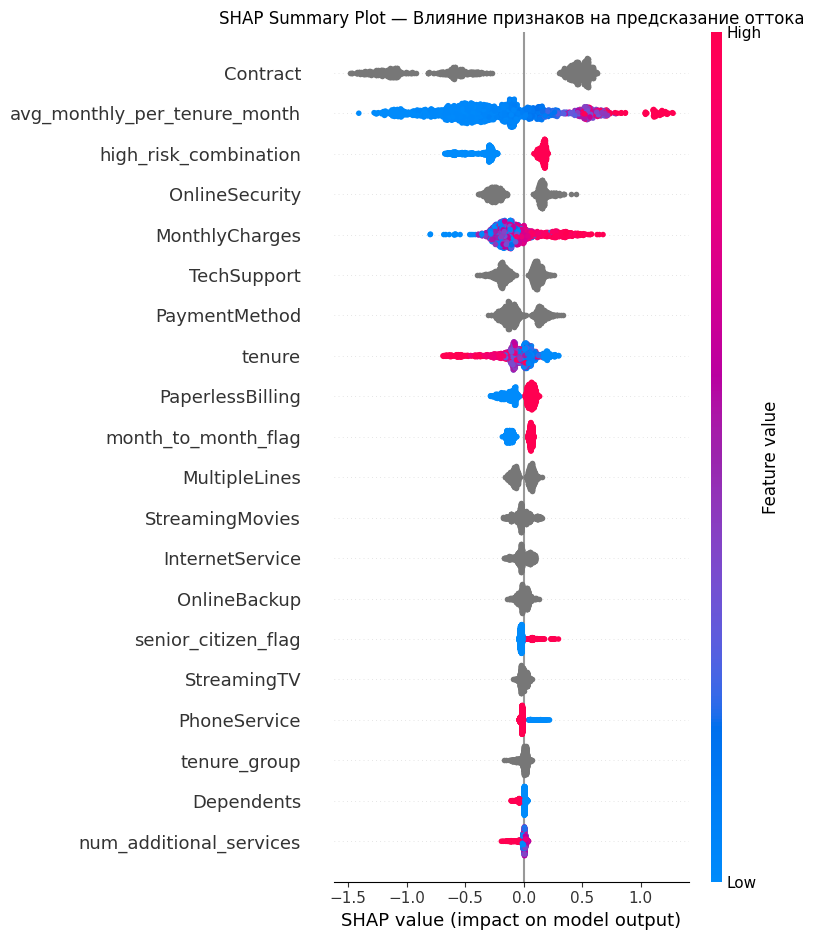


Пример объяснения предсказания для одного клиента


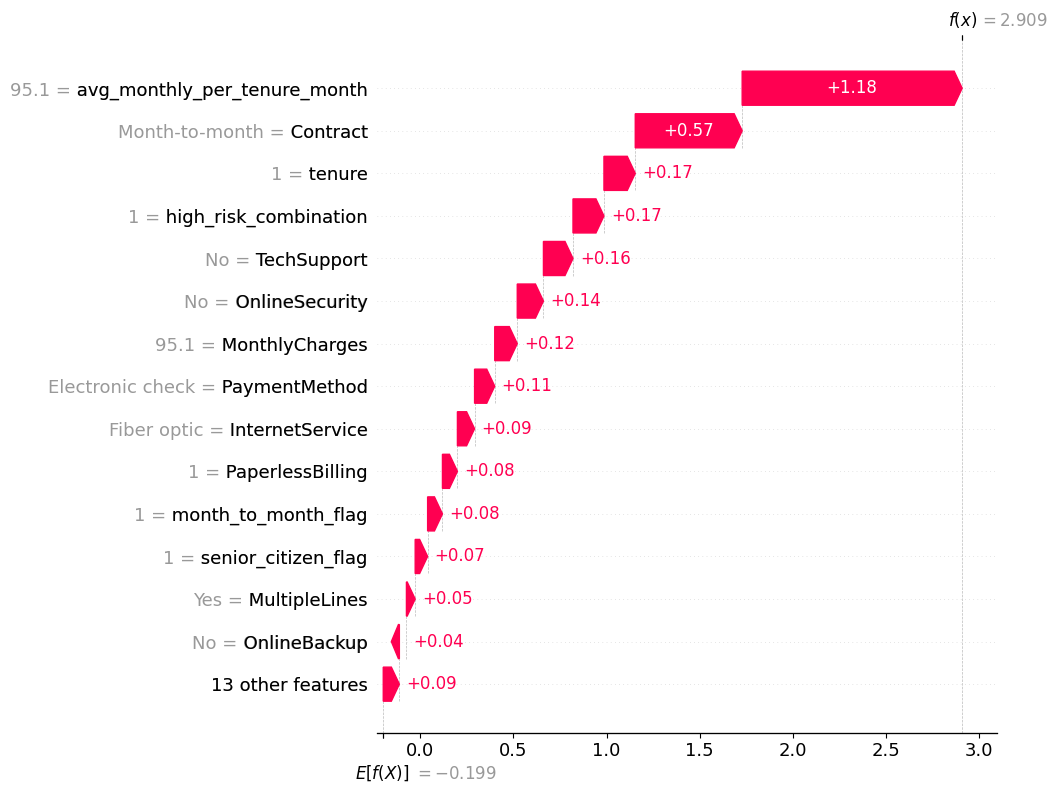


Топ-10 самых важных признаков по SHAP:


,feature,mean_shap
0,Contract,0.6658
1,avg_monthly_per_tenure_month,0.4620
2,high_risk_combination,0.2576
3,OnlineSecurity,0.2114
4,MonthlyCharges,0.1736
5,TechSupport,0.1525
6,PaymentMethod,0.1333
7,tenure,0.1236
8,PaperlessBilling,0.0896
9,month_to_month_flag,0.0863


In [8]:
# SHAP Analysis

explainer = shap.TreeExplainer(final_model)

# Вычисляем SHAP значения для тестового набора
shap_values = explainer.shap_values(X_test)

# Summary Plot (Beeswarm) 
print("SHAP Summary Plot (Global Importance)")

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, plot_type="dot", show=False)
plt.title("SHAP Summary Plot — Влияние признаков на предсказание оттока")
plt.tight_layout()
plt.show()

shap_df = pd.DataFrame(shap_values, columns=X_test.columns)

# Среднее абсолютное влияние признака
mean_shap = np.abs(shap_df).mean().sort_values(ascending=False).head(15).reset_index()
mean_shap.columns = ['feature', 'mean_shap']

fig_shap = px.bar(
    mean_shap,
    x='mean_shap',
    y='feature',
    orientation='h',
    title='Топ-15 признаков по среднему влиянию (SHAP)',
    labels={'mean_shap': 'Среднее абсолютное SHAP значение', 'feature': 'Признак'},
    color='mean_shap',
    color_continuous_scale='RdYlBu_r'
)

fig_shap.update_layout(height=650, width=950, yaxis=dict(autorange="reversed"))
fig_shap.show()

# Waterfall Plot
print("\nПример объяснения предсказания для одного клиента")

high_risk_idx = np.argsort(y_pred_proba)[-1] 

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[high_risk_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[high_risk_idx],
        feature_names=X_test.columns.tolist()
    ),
    max_display=15
)

# Топ-10 признаков в табличном виде
print("\nТоп-10 самых важных признаков по SHAP:")
display(mean_shap.head(10).style.format({'mean_shap': '{:.4f}'}))